- 실습 기본 환경 설정


In [18]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 9-2 Seq2Seq 모델의 배치 학습

본 노트북은 9-2절 본문 예제 [코드 9-13]~[코드 9-18]을 모아 위에서 아래로
실행해 본다. 9-1절의 날짜 변환기 모델을 가변 길이 미니 배치 학습이 가능하도록
수정한다.

다루는 내용
- `<pad>`를 추가한 어휘 사전과 데이터셋 ([코드 9-13])
- 배치 병합 함수와 배치 데이터로더 ([코드 9-14])
- 패킹/언패킹을 적용한 인코더, 길이 정보 텐서 전달 ([코드 9-15]~[코드 9-17])
- `<pad>` 위치 손실을 무시하는 손실 함수와 미니 배치 학습 ([코드 9-18])

검증 함수와 학습 루프는 본문 미공개이므로 노트북에서 직접 정의한다.

In [19]:
# 참고 - 데이터 생성 함수
from datetime import datetime, timedelta
import random

src_formats = [
    '%d %B %Y',     # 01 February 2026
    '%d %b %Y',     # 01 Feb 2026
    '%B %d, %Y',    # February 01, 2026
    '%b %d, %Y',    # Feb 01, 2026
    '%m/%d/%Y',     # 02/01/2026
    '%Y/%m/%d',     # 2026/02/01
    '%d-%m-%Y',     # 01-02-2026
    '%Y-%m-%d',     # 2026-02-01
]

# 시작일(start_date)과 종료일(end_date) 사이의 sample_size개의 무작위 날짜 선택
def choice_random_dates(sample_size=1, start_date=None, end_date=None):
    if start_date is None:
        start_date = datetime(1900, 1, 1)
    if end_date is None:
        end_date = datetime(2050, 12, 31)
    days_between = (end_date - start_date).days
    datetime_list = []
    for _ in range(sample_size):
        days_after = random.randrange(days_between)
        datetime_list.append(start_date + timedelta(days=days_after))
    return datetime_list

# datetime 리스트를 입력 리스트와 정답 리스트로 변환하는 함수
# 입력은 src_formats에 정의된 형식으로, 정답은 'YYYY-M-D' 형식으로 변환
def generate_datepairs(date_list, src_formats=src_formats):
    if len(src_formats) == 0:
        raise ValueError('입력 문자열 템플릿이 비어 있습니다.')
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(date.strftime(src_format))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates


# 4,000개의 (입력, 정답) 날짜 쌍 생성
date_list = choice_random_dates(4000)
src_dates, tgt_dates = generate_datepairs(date_list)
print(f'생성된 날짜 쌍의 수: {len(src_dates)}')

생성된 날짜 쌍의 수: 4000


## [코드 9-13] 배치 구성을 위한 어휘 사전과 데이터셋 수정

배치 패딩을 위해 어휘 사전에 `<pad>`를 추가하고, 텐서 변환을 배치 병합으로
미루기 위해 `__getitem__()`이 정수 리스트를 반환하도록 수정한다.

In [20]:
########################################################################################
# 코드 9-12 - 배치 구성을 위한 어휘 사전과 데이터셋
########################################################################################

from torch.utils.data import Dataset

# 특수 토큰 조합에 <pad> 추가
SOS_TOKEN, EOS_TOKEN, PAD_TOKEN = '<sos>', '<eos>', '<pad>'
SOS_IDX, EOS_IDX, PAD_IDX = 0, 1, 2
special_tokens = {SOS_TOKEN: SOS_IDX, EOS_TOKEN: EOS_IDX, PAD_TOKEN: PAD_IDX}

# 어휘 사전 클래스(Vocab)는 9-1절과 동일
class Vocab:
    def __init__(self, sequence_list, special_tokens):
        tokens = set()
        for sequence in sequence_list:
            tokens.update(sequence)
        self.vocab = dict(special_tokens)
        idx_start = len(special_tokens)
        for i, token in enumerate(sorted(tokens)):
            self.vocab[token] = i + idx_start
        self.itos = {idx: token for token, idx in self.vocab.items()}

    def encode(self, input_sequence):
        return [self.vocab[token] for token in input_sequence]

    def decode(self, input_ids):
        return [self.itos[idx] for idx in input_ids]

    def __len__(self):
        return len(self.vocab)

# 데이터셋 클래스: 텐서 변환 제거
class DateDataset(Dataset):
    def __init__(self, src_dates, tgt_dates, src_vocab, tgt_vocab):
        self.samples = []
        for src_date, tgt_date in zip(src_dates, tgt_dates):
            src_ids = src_vocab.encode(src_date)
            tgt_ids = tgt_vocab.encode(tgt_date)
            tgt_ids = [SOS_IDX] + tgt_ids + [EOS_IDX]
            self.samples.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        src_ids, tgt_ids = self.samples[idx]
        # 텐서 변환 없이 정수 리스트를 반환(데이터로더가 텐서로 변환해 모델에 전달)
        return src_ids, tgt_ids


src_vocab = Vocab(src_dates, special_tokens)
tgt_vocab = Vocab(tgt_dates, special_tokens)
train_set = DateDataset(src_dates[:3000], tgt_dates[:3000], src_vocab, tgt_vocab)
valid_set = DateDataset(src_dates[3000:], tgt_dates[3000:], src_vocab, tgt_vocab)
print(f'입력 어휘 사전 크기: {len(src_vocab)} (<pad> 포함)')
print(f'출력 어휘 사전 크기: {len(tgt_vocab)} (<pad> 포함)')

입력 어휘 사전 크기: 43 (<pad> 포함)
출력 어휘 사전 크기: 14 (<pad> 포함)


## [코드 9-14] 배치 병합 함수를 정의해 배치 데이터로더 생성

`collate_fn`은 데이터로더가 배치를 구성한 뒤 호출되는 콜백으로, 각 샘플을
텐서로 변환하고 `pad_sequence()`로 가장 긴 샘플에 맞춰 `<pad>`를 채운다.

In [21]:
########################################################################################
# 코드 9-13 - 배치 병합 함수를 정의해 배치 데이터로더 생성
########################################################################################
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

# 날짜 변환기 모델 학습용 데이터로더의 배치 병합 함수
#   : 하나의 배치에 포함된 샘플(튜플)의 리스트가 batch 인자에 전달됨
def collate_fn(batch):    
    # (입력, 정답)의 튜플 리스트를 입력 리스트 튜플과 정답 리스트 튜플로 분리
    src_batch, tgt_batch = zip(*batch)
    # 입력과 정답의 리스트를 각각 정수형(torch.long) 텐서로 변환
    src_tensors = [torch.tensor(s, dtype=torch.long) for s in src_batch]
    tgt_tensors = [torch.tensor(t, dtype=torch.long) for t in tgt_batch]
    
    # pad_sequence(): 가장 긴 샘플에 맞춰 나머지 샘플 끝에 padding_value를 채움
    #     batch_first=True -> (B, max_length) 형태로 반환
    #     batch_first=False -> (max_length, B) 형태로 반환
    #     리스트를 입력해도 텐서를 반환하며, 다시 텐서로 바꿀 필요가 없음
    src_padded = pad_sequence(src_tensors, batch_first=True, padding_value=PAD_IDX)
    tgt_padded = pad_sequence(tgt_tensors, batch_first=True, padding_value=PAD_IDX)

    # 배치 텐서를 반환
    return src_padded, tgt_padded

# 배치 크기 32인 데이터로더 생성
BATCH_SIZE = 32
# collate_fn 인자에 배치 병합 함수 지정
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, 
                          collate_fn=collate_fn)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False, 
                          collate_fn=collate_fn)

# 첫 배치 형태 확인
src_batch, tgt_batch = next(iter(train_loader))
print(f'src 배치 형태: {tuple(src_batch.shape)} (B, src_max_length)')
print(f'tgt 배치 형태: {tuple(tgt_batch.shape)} (B, tgt_max_length)')

src 배치 형태: (32, 17) (B, src_max_length)
tgt 배치 형태: (32, 12) (B, tgt_max_length)


## [코드 9-15]~[코드 9-17] 패킹/언패킹을 적용한 모델

인코더는 LSTM 직전에 임베딩을 패킹해 `<pad>`를 건너뛰게 한다([코드 9-17]).
길이 정보 텐서는 학습 함수에서 `(src != PAD_IDX).sum(dim=1)`로 만들어
([코드 9-15]) `DateConverter`를 거쳐 인코더까지 전달한다([코드 9-16]).
디코더는 9-1절과 동일하다.

In [22]:
########################################################################################
# 코드 9-14, 9-15 - 학습 함수에서 길이 정보 텐서를 만들어 모델에 전달
########################################################################################
import torch.nn as nn

# 9-1절의 1 에포크 학습 함수에서 길이 정보 텐서 생성 및 전달 부분 수정
def train_epoch(model, train_loader, criterion, optimizer, device=None):
    if device is None: device = torch.device('cpu')
    model.train()
    total_loss, token_count = 0.0, 0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        # 코드 9-14: (B, ) 형태의 길이 정보 텐서 생성
        src_lengths = (src != PAD_IDX).sum(dim=1)
        optimizer.zero_grad()
        # 코드 9-15: 학습 과정에서 모델에 길이 정보 텐서 전달
        logits = model(src, tgt, src_lengths)
        labels = tgt[:, 1:]
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        # 추가한 <pad> 위치를 제외하고 계산
        n_tokens = (labels != PAD_IDX).sum().item()
        total_loss += loss.item() * n_tokens
        token_count += n_tokens
    return total_loss / token_count

# 9-1절의 클래스 정의에 인코더에 길이 정보 텐서 전달 부분 추가
class DateConverter(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, src_lengths, forcing_ratio=0.5):  # src_lengths 인자 추가
        hidden, cell = self.encoder(src, src_lengths)             # 인코더에 전달
        context = hidden[-1].unsqueeze(1)              
        tgt_input = tgt[:, :-1]                        
        logits = self.decoder(tgt_input, hidden, cell, context, forcing_ratio)
        return logits


In [23]:
########################################################################################
# 코드 9-16 - 인코더 LSTM 계층 입력의 패킹과 출력의 언패킹
########################################################################################
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

# LSTM의 입력에 패킹을 적용한 인코더 클래스
class Encoder(nn.Module):
    def __init__(self, src_vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()
        self.encoder_embedding = nn.Embedding(src_vocab_size, embed_dim)
        self.encoder_lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers, batch_first=True
        )

    def forward(self, src, src_lengths):            # src_lengths(길이 정보 텐서) 추가
        embedded = self.encoder_embedding(src)      # (B, S, embed_dim)
        # 임베딩 벡터를 패킹: LSTM이 <pad>를 건너뛰게 만듦
        packed_embedding = pack_padded_sequence(
            embedded, src_lengths.cpu(),            # 길이 정보 텐서는 반드시 CPU에 있어야 함
            batch_first=True, enforce_sorted=False,
        )
        packed_output, (hidden, cell) = self.encoder_lstm(packed_embedding)
        # output 사용이 필요한 경우 다음과 같이 언패킹해서 (B, S, hidden_dim)으로 복원
        # from torch.nn.utils.rnn import pad_packed_sequence
        # output, _ = pad_packed_sequence(packed_output, batch_first=True)
        return hidden, cell



In [24]:
# 참고 - Decoder 클래스 (9-1절과 동일)

class Decoder(nn.Module):
    def __init__(self, tgt_vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, embed_dim)
        self.decoder_lstm = nn.LSTM(
            embed_dim + hidden_dim, hidden_dim,
            num_layers=num_layers, batch_first=True,
        )
        self.fc = nn.Linear(hidden_dim, tgt_vocab_size)

    def forward_step(self, token, hidden, cell, context):
        embedded = self.decoder_embedding(token)
        rnn_input = torch.cat([embedded, context], dim=-1)
        output, (hidden, cell) = self.decoder_lstm(rnn_input, (hidden, cell))
        logits = self.fc(output.squeeze(1))
        return logits, hidden, cell

    def forward(self, tgt, hidden, cell, context, forcing_ratio=0.5):
        _, T = tgt.shape
        all_logits = []
        token = tgt[:, 0:1]
        for i in range(T):
            logits, hidden, cell = self.forward_step(token, hidden, cell, context)
            all_logits.append(logits.unsqueeze(1))
            if i + 1 < T:
                use_teacher_forcing = random.random() < forcing_ratio
                if use_teacher_forcing:
                    token = tgt[:, i + 1:i + 2]
                else:
                    token = logits.argmax(dim=-1, keepdim=True)
        return torch.cat(all_logits, dim=1)

In [25]:
# ###############################################################################
# # 코드 9-16 - 길이 정보 텐서를 인코더까지 전달하도록 수정한 DateConverter
# ###############################################################################
# class DateConverter(nn.Module):
#     def __init__(self, encoder, decoder):
#         super().__init__()
#         self.encoder = encoder
#         self.decoder = decoder

#     def forward(self, src, tgt, src_lengths):          # src_lengths 인자 추가
#         hidden, cell = self.encoder(src, src_lengths)  # 인코더에 전달
#         context = hidden[-1].unsqueeze(1)              # (B, 1, hidden_dim)
#         tgt_input = tgt[:, :-1]                        # <eos> 제거
#         logits = self.decoder(tgt_input, hidden, cell, context)
#         return logits

In [26]:
# 참고 - 검증 함수 및 학습 루프

import copy

# 검증 함수: 학습 함수와 마찬가지로 패딩을 위한 길이 정보 텐서를 만들고 모델에 입력
@torch.no_grad()
def validation(model, valid_loader, criterion, device=None):
    if device is None:
        device = torch.device('cpu')
    model.eval()
    total_loss, token_count = 0.0, 0
    correct_size, sample_size = 0, 0
    for src, tgt in valid_loader:
        src, tgt = src.to(device), tgt.to(device)
        # 검증에서도 길이 정보 텐서 생성 및 전달이 필요
        src_lengths = (src != PAD_IDX).sum(dim=1)
        logits = model(src, tgt, src_lengths, forcing_ratio=0.0)
        labels = tgt[:, 1:]
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
        )
        n_tokens = (labels != PAD_IDX).sum().item()
        total_loss += loss.item() * n_tokens
        token_count += n_tokens
        preds = logits.argmax(dim=-1)
        mask = labels != PAD_IDX
        # <pad> 위치를 제외하고 샘플 별 정답/오답을 판정해 취합
        sample_correct = ((preds == labels) | ~mask).all(dim=1)
        correct_size += sample_correct.sum().item()
        sample_size += src.size(0)
    return total_loss / token_count, correct_size / sample_size * 100.0



# 학습 루프는 9-1절과 동일
def train_with_early_stopping(model, train_loader, valid_loader, criterion, optimizer, 
                              epochs, patience, device=None):
    if device is None: 
        device = torch.device('cpu')
    model.to(device)
    # 학습 로거 설정
    log = common.EpochLogger(epochs, target_rows=epochs)
    best_valid_loss = float('inf')
    best_state, counter = None, 0
    stopped = False
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = validation(model, valid_loader, criterion, device)
        log.row(epoch, train_loss, valid_loss, valid_acc)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:            # 최적 모델 갱신
            best_valid_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            counter = 0
        else:                                       
            counter += 1
            if counter >= patience:                 # 조기 종료 조건 만족시 조기 종료
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)           # 최적 모델로 복원

    # log.summary(): 학습 결과를 요약해 출력하는 메서드
    log.summary(stopped='조기 종료' if stopped else None)

    return log    

## [코드 9-18] PAD 위치의 손실을 무시하는 손실 함수와 학습 함수

`CrossEntropyLoss(ignore_index=PAD_IDX)`는 정답의 `<pad>` 위치를 손실
계산에서 제외한다. 학습 함수는 [코드 9-15]의 길이 정보 텐서를 만들어
[코드 9-16]의 모델로 전달한다.

In [27]:
########################################################################################
# 코드 9-17 - PAD 위치의 손실을 무시하는 교차 엔트로피 손실 함수
########################################################################################
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
print(f'ignore_index = {PAD_IDX} (<pad> 위치는 손실 계산에서 제외)')

ignore_index = 2 (<pad> 위치는 손실 계산에서 제외)


In [28]:
# ########################################################################################
# # 코드 9-14, 9-15 - 학습 함수에서 길이 정보 텐서를 만들어 모델에 전달
# ########################################################################################

# # 9-1절의 학습 함수와 거의 동일하지만, 길이 정보 텐서를 만들어 전달하는 부분이 달라짐
# def train_epoch(model, train_loader, criterion, optimizer, device=None):
#     if device is None: device = torch.device('cpu')
#     model.train()
#     total_loss, token_count = 0.0, 0
#     for src, tgt in train_loader:
#         src, tgt = src.to(device), tgt.to(device)
#         # 코드 9-14: (B, ) 형태의 길이 정보 텐서 생성
#         src_lengths = (src != PAD_IDX).sum(dim=1)
#         optimizer.zero_grad()
#         # 코드 9-15: 학습 과정에서 모델에 길이 정보 텐서 전달
#         logits = model(src, tgt, src_lengths)
#         labels = tgt[:, 1:]
#         loss = criterion(
#             logits.reshape(-1, logits.size(-1)),
#             labels.reshape(-1)
#         )
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()
#         # 추가한 <pad> 위치를 제외하고 계산
#         n_tokens = (labels != PAD_IDX).sum().item()
#         total_loss += loss.item() * n_tokens
#         token_count += n_tokens
#     return total_loss / token_count


In [29]:
# # 참고 - 검증 및 학습 함수

# @torch.no_grad()
# def validation_epoch(model, valid_loader, criterion, device=None):
#     if device is None:
#         device = torch.device('cpu')
#     model.eval()
#     total_loss, token_count = 0.0, 0
#     correct_size, sample_size = 0, 0
#     for src, tgt in valid_loader:
#         src, tgt = src.to(device), tgt.to(device)
#         src_lengths = (src != PAD_IDX).sum(dim=1)
#         logits = model(src, tgt, src_lengths)
#         labels = tgt[:, 1:]
#         loss = criterion(
#             logits.reshape(-1, logits.size(-1)),
#             labels.reshape(-1),
#         )
#         n_tokens = (labels != PAD_IDX).sum().item()
#         total_loss += loss.item() * n_tokens
#         token_count += n_tokens
#         preds = logits.argmax(dim=-1)
#         mask = labels != PAD_IDX
#         sample_correct = ((preds == labels) | ~mask).all(dim=1)
#         correct_size += sample_correct.sum().item()
#         sample_size += src.size(0)
#     return total_loss / token_count, correct_size / sample_size * 100.0


# # 조기 종료 방식으로 모델을 학습하는 학습 루프 함수
# def train_with_early_stopping(model, train_loader, valid_loader, criterion, optimizer, 
#                               epochs, patience, device=None):
#     if device is None:
#         device = torch.device('cpu')
#     model.to(device)
#     log = common.EpochLogger(epochs, target_rows=epochs)        
#     best_valid_loss = float('inf')
#     best_state, counter = None, 0
#     stopped = False
#     for epoch in range(1, epochs + 1):
#         train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
#         valid_loss, valid_acc = validation_epoch(model, valid_loader, criterion, device)
#         # valid_acc는 이미 백분율 수(0~100)
#         log.row(epoch, train_loss, valid_loss, valid_acc)
#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss
#             best_state = copy.deepcopy(model.state_dict())
#             counter = 0
#         else:
#             counter += 1
#             if counter >= patience:
#                 stopped = True
#                 break
#     if best_state is not None:
#         model.load_state_dict(best_state)

#     log.summary(stopped='조기 종료' if stopped else None)
#     return log

## 미니 배치 학습 실행 - [표 9-3] 첫 번째 행 재현

배치 크기 32, 패킹 적용 환경에서 학습한다. 9-1절(배치 크기 1)과 비교하면
에포크당 학습 시간이 크게 줄어든다.

In [30]:
# 참고 - 모델 객체 생성과 학습

import torch.optim as optim

# 하이퍼파라미터 설정
EMBED_DIM = 32
HIDDEN_DIM = 32
NUM_LAYERS = 1
LR = 1e-3
EPOCHS = 200
PATIENCE = 5

# 결과 재현을 위한 시드값 설정
common.set_seed(SEED)

# 인코더와 디코더를 생성한 후, 이를 주입해 모델 객체 생성
encoder = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
decoder = Decoder(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
model = DateConverter(encoder, decoder).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

log = train_with_early_stopping(
    model, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device
)

 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       2.1728       1.7630        0.00%     0:02
  2/200       1.5823       1.5131        0.00%     0:03
  3/200       1.3467       1.3692        0.00%     0:05
  4/200       1.1849       1.2209        0.50%     0:07
  5/200       1.0476       1.0747        0.40%     0:09
  6/200       0.9429       0.9673        0.80%     0:10
  7/200       0.8557       0.9046        1.10%     0:12
  8/200       0.7900       0.8397        2.00%     0:13
  9/200       0.7388       0.8029        2.60%     0:15
 10/200       0.6946       0.7577        3.20%     0:16
 11/200       0.6506       0.7066        5.60%     0:19
 12/200       0.6098       0.6803        8.30%     0:21
 13/200       0.5693       0.6440       10.80%     0:22
 14/200       0.5432       0.6099       13.10%     0:24
 15/200       0.5091       0.5859       13.40%     0:25
 16/200       0.4733       0.5504       20.40%     0:27
 17/200       0.4384       0.5211       23.20%     0:28
 18/200 

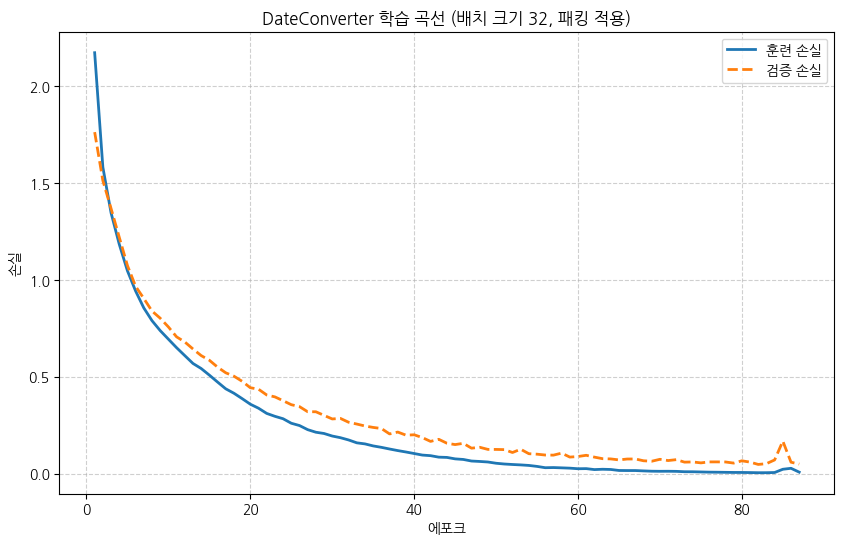

In [31]:
# 참고 - 학습 곡선 시각화
log.plot(title='DateConverter 학습 곡선 (배치 크기 32, 패킹 적용)')

## 학습된 모델로 변환 결과 확인

미니 배치 모델은 한 샘플을 예측할 때도 `src_lengths`를 함께 전달해야 한다.

In [32]:
# 참고 - 예측 함수, 1 샘플을 예측할 때도 길이 정보 텐서가 필요
@torch.no_grad()
def predict(model, src_text, src_vocab, tgt_vocab, device=None, max_length=12):
    if device is None:
        device = torch.device('cpu')
    model.eval()
    src_ids = src_vocab.encode(src_text)
    src = torch.LongTensor(src_ids).unsqueeze(0).to(device)
    # 1 샘플 예측에도 길이 정보 필요
    src_lengths = torch.tensor([len(src_ids)], dtype=torch.long)  
    hidden, cell = model.encoder(src, src_lengths)
    context = hidden[-1].unsqueeze(1)
    tgt_token = torch.tensor([[SOS_IDX]]).to(device)
    result_ids = []
    for _ in range(max_length):
        logits, hidden, cell = model.decoder.forward_step(
            tgt_token, hidden, cell, context,
        )
        prediction = logits.argmax(dim=-1, keepdim=True)
        if prediction.item() == EOS_IDX:
            break
        result_ids.append(prediction.item())
        tgt_token = prediction
    return ''.join(tgt_vocab.decode(result_ids))


# 임의 날짜 하나를 여덟 형식으로 테스트
common.set_seed(SEED)
test_date = choice_random_dates(1) * 8
test_src, test_tgt = generate_datepairs(test_date)
print(f'정답 날짜 문자열: {test_tgt[0]}')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(test_src, test_tgt):
    pred = predict(model, src_text, src_vocab, tgt_vocab, device)
    mark = '정답' if pred == tgt_text else '오답'
    print(f'  {src_text:<40s} => {pred} ({mark})')

정답 날짜 문자열: 2014-9-25
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)
  25 September 2014                        => 2014-9-25 (정답)
  25 Sep 2014                              => 2014-9-25 (정답)
  September 25, 2014                       => 2014-9-25 (정답)
  Sep 25, 2014                             => 2014-9-25 (정답)
  09/25/2014                               => 2014-9-25 (정답)
  2014/09/25                               => 2014-9-25 (정답)
  25-09-2014                               => 2014-9-25 (정답)
  2014-09-25                               => 2014-9-25 (정답)


## 정리 ([표 9-3] 비교)

- 가변 길이 순차 데이터의 미니 배치 학습은 패딩 -> 배치 병합 함수 ->
  패킹 -> 언패킹의 4단계 표준 절차를 따른다.
- `pad_sequence()`, `pack_padded_sequence()`, `pad_packed_sequence()` 세
  함수가 각 단계의 도구이며, `CrossEntropyLoss(ignore_index=PAD_IDX)`로
  손실 계산에서 `<pad>` 위치를 제외한다.
- 미니 배치(배치 크기 32) 학습은 9-1절의 배치 크기 1 대비 에포크당 학습
  시간이 압도적으로 짧아 전체 학습이 훨씬 빨리 끝난다. 다만 같은 학습률에서
  최적 에포크에 도달하기까지 더 많은 에포크가 필요하다.

## 노이즈 데이터셋으로 미니 배치 재학습 (참고)

9-3절 `data.ipynb`의 노이즈 데이터 생성법으로, 입력 날짜 문자열 앞뒤에 무작위
문자를 덧붙인 최대 40자 입력을 만들어 미니 배치 방식으로 재학습한다. 어휘
사전·데이터셋·데이터로더·모델은 모두 새로(`_noisy`) 만들고, 미니 배치 구성
(`collate_fn`, 패킹)은 그대로 사용한다.

In [33]:
# 참고 - 노이즈 데이터 생성 함수(9-3절의 데이터 생성 함수와 동일)

import string

# 날짜 문자열 앞뒤에 무작위 길이의 무작위 노이즈를 덧붙인 문자열 생성
def add_random_noise(text, max_length=40):
    noise_chars = (
        string.ascii_letters + string.digits + '!@#$%^&*()_+-=[]{}|;:,./<>?'
    )
    prefix, suffix = '', ''
    remaining = max_length - len(text)
    if remaining > 0:
        prefix_length = random.randint(0, remaining)
        remaining -= prefix_length
        prefix = ''.join(random.choices(noise_chars, k=prefix_length))
    if remaining > 0:
        suffix_length = random.randint(0, remaining)
        suffix = ''.join(random.choices(noise_chars, k=suffix_length))
    return prefix + text + suffix

# 노이즈가 추가된 날짜 문자열 쌍 생성 함수
def generate_noisy_datepairs(date_list, src_formats=src_formats):
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(add_random_noise(date.strftime(src_format)))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates


In [34]:
# 참고 - DateConverter 모델을 노이즈 추가 데이터로 학습하고 결과 확인

import string

def show_sample_result(src_text, tgt_text, predicted_text):
    mark = '정답' if predicted_text == tgt_text else '오답'
    return f'  {src_text:<40s} => {predicted_text} ({mark})'

PATIENCE = 5
EPOCHS = 500

# 결과 고정을 위한 시드값 설정
common.set_seed(SEED)

# 노이즈 데이터셋 생성 (4,000쌍)
date_list_noisy = choice_random_dates(4000)
src_dates_noisy, tgt_dates_noisy = generate_noisy_datepairs(date_list_noisy)
print('노이즈 데이터셋 예시:')
for i in range(2):
    print(f'  {src_dates_noisy[i]!r} -> {tgt_dates_noisy[i]!r}')

# 노이즈 문자를 포함한 어휘 사전 생성
src_vocab_noisy = Vocab(src_dates_noisy, special_tokens)
tgt_vocab_noisy = Vocab(tgt_dates_noisy, special_tokens)
print(f'입력 어휘 사전 크기: {len(src_vocab)} -> {len(src_vocab_noisy)}')
print(f'출력 어휘 사전 크기: {len(tgt_vocab)} -> {len(tgt_vocab_noisy)}')

# 데이터셋과 데이터로더 생성
train_set_noisy = DateDataset(
    src_dates_noisy[:3000], tgt_dates_noisy[:3000], src_vocab_noisy, tgt_vocab_noisy)
valid_set_noisy = DateDataset(
    src_dates_noisy[3000:], tgt_dates_noisy[3000:], src_vocab_noisy, tgt_vocab_noisy)
train_loader_noisy = DataLoader(
    train_set_noisy, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_loader_noisy = DataLoader(
    valid_set_noisy, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# 모델 객체를 생성해 학습
encoder_noisy = Encoder(len(src_vocab_noisy), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
decoder_noisy = Decoder(len(tgt_vocab_noisy), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
model_noisy = DateConverter(encoder_noisy, decoder_noisy).to(device)

optimizer_noisy = optim.Adam(model_noisy.parameters(), lr=LR)
history_noisy = train_with_early_stopping(
    model_noisy, train_loader_noisy, valid_loader_noisy, criterion, optimizer_noisy,
    epochs=EPOCHS, patience=PATIENCE, device=device,
)

# 결과 확인

common.set_seed(SEED)                       # 이전 테스트와 같은 날짜가 생성되도록 시드값 지정
test_date = choice_random_dates(1) * 8
clean_src, clean_tgt = generate_datepairs(test_date)
noisy_src, noisy_tgt = generate_noisy_datepairs(test_date)

print(f'\n정답 날짜 문자열: {clean_tgt[0]}')
print('노이즈 없는 날짜 문자열 변환:')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(clean_src, clean_tgt):
    pred = predict(model_noisy, src_text, src_vocab_noisy, tgt_vocab_noisy, device)
    print(show_sample_result(src_text, tgt_text, pred))

print('\n노이즈를 추가한 날짜 문자열 변환:')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(noisy_src, noisy_tgt):
    pred = predict(model_noisy, src_text, src_vocab_noisy, tgt_vocab_noisy, device)
    print(show_sample_result(src_text, tgt_text, pred))

노이즈 데이터셋 예시:
  'uKq5Mc2r0I!s%)25 September 2014Z' -> '2014-9-25'
  ']qDOx[U4120E=2_!A2hlkBq9T24 Dec 19191ZL' -> '1919-12-24'
입력 어휘 사전 크기: 43 -> 93
출력 어휘 사전 크기: 14 -> 14
 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/500       2.2359       1.8393        0.00%     0:02
  2/500       1.6806       1.6586        0.00%     0:03
  3/500       1.4987       1.5118        0.00%     0:05
  4/500       1.3713       1.4080        0.00%     0:07
  5/500       1.2810       1.3318        0.00%     0:09
  6/500       1.2111       1.2750        0.00%     0:10
  7/500       1.1696       1.2444        0.00%     0:12
  8/500       1.1267       1.2137        0.00%     0:13
  9/500       1.1052       1.1712        0.10%     0:15
 10/500       1.0758       1.1665        0.00%     0:17
 11/500       1.0413       1.1104        0.10%     0:18
 12/500       1.0034       1.0749        0.20%     0:20
 13/500       0.9768       1.0555        0.20%     0:22
 14/500       0.9370       1.0362        0.20%     0:24
 15/500